<a href="https://colab.research.google.com/github/soleildayana/Modern-Astrophysics/blob/main/AstroModerna_Proyecto_I.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Primer Proyecto Computacional - Astrofísica Moderna
## Astronomía - Universidad de Antioquia
**Soleil Dayana Niño Murcia**

In [ ]:
# Librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import odeint

## Problema 1: Sintetización Monte Carlo de la silueta de un aguero negro con Ray Tracing

En este problema vamos a simular el efecto de lente gravitacional que experimenta la luz que sale de un
disco delgado alrededor de un agujero negro. Para lograr esto, lanzaremos rayos de luz hacia el agujero
negro desde una ”pantalla” de observaci ́on distante1

, distribuidos inicialmente sobre una regi ́on circular en
el plano yz. Cada rayo se propaga a trav ́es de un medio refractivo, donde el  ́ındice de refracci ́on depende
de la distancia radial al agujero negro, imitando as ́ı el desv ́ıo de los rayos de luz por la curvatura del
espacio-tiempo
El disco se modela como un anillo plano centrado en el origen, inclinado con respecto al observador seg ́un un
 ́angulo dado. Para cada rayo, el c ́odigo debe determinar si impacta el disco o si es capturado por el agujero
negro, y esta informaci ́on se utiliza para asignar brillo a p ́ıxeles en el plano de imagen. El resultado final es
una imagen simulada con lente gravitacional que muestra la geometr ́ıa aparente de la sombra del agujero
negro y la apariencia distorsionada del disco inclinado visto por un observador distante. Por conveniencia
trabajaremos todo el problema sin unidades (unidades naturales).

### Parte 1: Propagación de Rayos de Luz en un ST Curvo mediante Aproximación Eikonal

In [3]:
N, R = 500, 70

r0 = R * np.sqrt(np.random.uniform(0, 1, N))
theta0 = 2 * np.pi * np.random.uniform(0, 1, N)

y0, z0 = r0 * np.sin(theta0), r0 * np.cos(theta0) # cilíndricas -> cartesianas

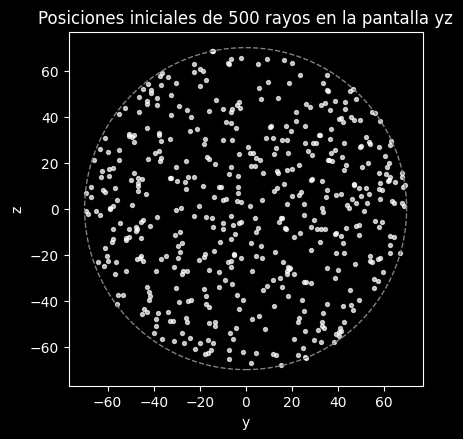

In [12]:
fig, ax = plt.subplots(figsize=(4.6, 4.6))
ax.scatter(y0, z0, s=8, c="white", alpha = 0.7)
ax.add_patch(plt.Circle((0, 0), R, fill=False, ls="--", color="gray")) # punteado en el radio
ax.set_xlabel("y")
ax.set_ylabel("z")
ax.set_aspect("equal")
ax.set_title(f"Posiciones iniciales de {N} rayos en la pantalla yz")
plt.show()

### Parte 2: Integración ed Rayos en el Plano xy
Ahora integraremos los rayos hacia adelante en el tiempo usando las ecuaciones diferenciales de la aproxi-
maci ́on eikonal. Para facilitar los c ́alculos, tomaremos inicialmente todos los rayos como coplanares (como

si estuvieran en el plano xy), y m ́as adelante los rotaremos a su  ́angulo original θ.

In [13]:
# ECUACIONES QUE DESCRIBEN LA TRAYECTORIA DEL RAYO

def refindex (x,y):
  eps = 1e-6 # corrección para evitar singularidades numéricas
  rp0 = np.sqrt(x**2 + y**2)
  n = 1 / (1 - A / (rp0 + eps))
  fac = np.abs((1 - 9* (A / rp0)**2 / 8))
  nx = -fac * n**2 * A * x / (rp0 + eps)**3
  ny = -fac * n**2 * A * y / (rp0 + eps)**3
  return n, nx, ny


def flow_deriv (x_y_z, tspan):
  x, y, z, w = x_y_z
  [n, nx, ny] = refindex(x,y)
  yp = np.zeros(shape=(4,))
  yp[0], yp[1], yp[2], yp[3] = z / n, w/n, nx, ny
  return yp

Inicialice el vector de estado 2D (en el plano xy) para cada rayo e integre hacia adelante en el tiempo.
Tome la posici ́on inicial de cada rayo como xstart = −100, ystart = r0, e integre para tspan ∈ [0, 400]
con un ∆t = 1.

In [15]:
A = 10    # Radio gravitacional del agujero negro

x_start = -100.0
t_span = np.arange(0, 401, 1) # Integra desde t=0 hasta t=400 con un paso de 1

# Lista para almacenar las trayectorias de todos los rayos
all_ray_trajectories = []

# La posición inicial de y para cada rayo es su r_0 correspondiente.
# Suponemos que los rayos inicialmente viajan paralelos al eje x desde x_start.
# El vector de estado es [x, y, dx/dt, dy/dt]
initial_x_dot = 1.0 # Velocidad inicial en x
initial_y_dot = 0.0 # Velocidad inicial en y

# Iterar sobre cada r_0 (que representa la y_initial) para cada rayo
for i in range(len(r0)): # r_0 se generó a partir de y,z cartesianas, representando la 'y' en este plano de integración.
    y_start_ray = r0[i]

    # Estado inicial para el rayo actual: [x, y, dx/dt, dy/dt]
    initial_state_ray = [x_start, y_start_ray, initial_x_dot, initial_y_dot]

    # Integra la trayectoria del rayo
    # La función flow_deriv espera (estado, t) donde estado es [x, y, z, w]
    # Y z, w son las derivadas dx/dt, dy/dt.
    # Aquí usamos la función flow_deriv previamente definida.
    trajectory = odeint(flow_deriv, initial_state_ray, t_span)
    all_ray_trajectories.append(trajectory)

print(f"Se integraron {len(all_ray_trajectories)} trayectorias de rayos.")
print("Primeras 5 pasos de la primera trayectoria (x, y, dx/dt, dy/dt):")
print(all_ray_trajectories[0][:5])

/tmp/ipykernel_3104/1126872476.py:26: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  trajectory = odeint(flow_deriv, initial_state_ray, t_span)


Se integraron 500 trayectorias de rayos.
Primeras 5 pasos de la primera trayectoria (x, y, dx/dt, dy/dt):
[[-1.00000000e+02  3.76538636e+01  1.00000000e+00  0.00000000e+00]
 [-9.90935089e+01  3.76536935e+01  1.00099590e+00 -3.76712737e-04]
 [-9.81868635e+01  3.76531782e+01  1.00200820e+00 -7.63144341e-04]
 [-9.72800620e+01  3.76523097e+01  1.00303726e+00 -1.15960331e-03]
 [-9.63731023e+01  3.76510788e+01  1.00408353e+00 -1.56645995e-03]]


Verifique si el rayo cae dentro del agujero negro, tomando A = 10 (es decir, verifique si p
x
2 + y
2 < A).
En caso afirmativo, trunque el rayo en el punto en el que intersecte con el agujero, indicando que la
trayectoria se detiene all ́ı.

In [16]:
# Radio gravitacional del agujero negro
A = 10

# Lista para almacenar las trayectorias de los rayos, potencialmente truncadas
updated_ray_trajectories = []
rays_hit_black_hole_count = 0

# all_ray_trajectories proviene de la celda de integración anterior
for ray_idx, trajectory in enumerate(all_ray_trajectories):
    x_coords = trajectory[:, 0]
    y_coords = trajectory[:, 1]

    # Calcular la distancia radial para todos los puntos en la trayectoria
    radial_distances = np.sqrt(x_coords**2 + y_coords**2)

    # Encontrar el primer índice donde la distancia radial es menor o igual a A
    hit_indices = np.where(radial_distances <= A)[0]

    if len(hit_indices) > 0:
        first_hit_index = hit_indices[0]
        # Truncar la trayectoria en el punto de impacto (inclusive)
        truncated_trajectory = trajectory[:first_hit_index + 1]
        updated_ray_trajectories.append(truncated_trajectory)
        rays_hit_black_hole_count += 1
    else:
        # Si el rayo no golpea el agujero negro, mantener la trayectoria completa
        updated_ray_trajectories.append(trajectory)

print(f"Se truncaron {rays_hit_black_hole_count} rayos por caer en el agujero negro (A={A}).")
print(f"Ahora tenemos {len(updated_ray_trajectories)} trayectorias de rayos (algunas truncadas).")

# Actualizar la lista global de trayectorias con las (potencialmente) truncadas
all_ray_trajectories = updated_ray_trajectories

# Opcional: mostrar la longitud de la primera trayectoria para verificar el truncamiento
if len(all_ray_trajectories) > 0:
    print("Longitud de la primera trayectoria (después de truncar, si aplica):", len(all_ray_trajectories[0]))

Se truncaron 138 rayos por caer en el agujero negro (A=10).
Ahora tenemos 500 trayectorias de rayos (algunas truncadas).
Longitud de la primera trayectoria (después de truncar, si aplica): 401


/tmp/ipykernel_3104/2791209431.py:14: RuntimeWarning: overflow encountered in square
  radial_distances = np.sqrt(x_coords**2 + y_coords**2)


Verifique si el rayo termina m ́as all ́a de un xmax o un ymax de 300, evitando posiciones extremas para
los rayos.

In [17]:
# Evitar posiciones extremas
if len(all_ray_trajectories) > 0:
    xmax, ymax = 300, 300
    all_ray_trajectories = [trajectory[(trajectory[:, 0] <= xmax) & (trajectory[:, 1] <= ymax)] for trajectory in all_ray_trajectories]
    print(f"Se evitaron posiciones extremas en {len(all_ray_trajectories)} trayectorias.")
    print("Primeras 5 pasos de la primera trayectoria (x, y, dx/dt, dy/dt) después de evitar posiciones extremas:")
    print(all_ray_trajectories[0][:5])
    print("Tamaño de la primera trayectoria después de evitar posiciones extremas:", len(all_ray_trajectories[0]))



Se evitraron posiciones extremas en 500 trayectorias.
Primeras 5 pasos de la primera trayectoria (x, y, dx/dt, dy/dt) después de evitar posiciones extremas:
[[-1.00000000e+02  3.76538636e+01  1.00000000e+00  0.00000000e+00]
 [-9.90935089e+01  3.76536935e+01  1.00099590e+00 -3.76712737e-04]
 [-9.81868635e+01  3.76531782e+01  1.00200820e+00 -7.63144341e-04]
 [-9.72800620e+01  3.76523097e+01  1.00303726e+00 -1.15960331e-03]
 [-9.63731023e+01  3.76510788e+01  1.00408353e+00 -1.56645995e-03]]
Tamaño de la primera trayectoria después de evitar posiciones extremas: 401


Graficar un subconjunto de trayectorias para verificar que la deflexión se hace correctamente

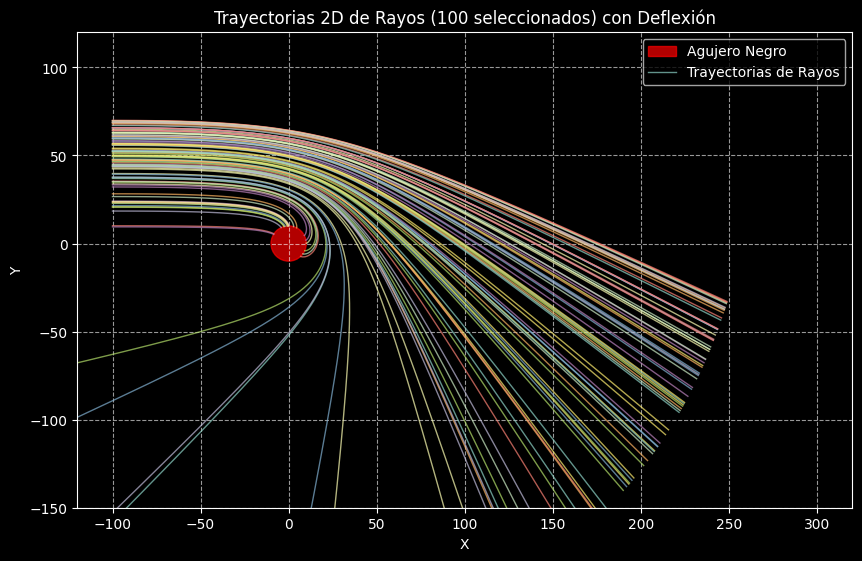

In [18]:
plt.figure(figsize=(10, 8))
plt.style.use('dark_background')

# Plot the black hole (if A is defined)
if 'A' in globals():
    black_hole_circle = plt.Circle((0, 0), A, color='red', alpha=0.7, label='Agujero Negro')
    plt.gca().add_patch(black_hole_circle)

# Plot a subset of rays (e.g., the first 20) to visualize deflection
num_rays_to_plot = 100

for i in range(min(num_rays_to_plot, len(all_ray_trajectories))):
    trajectory = all_ray_trajectories[i]
    x_coords = trajectory[:, 0]
    y_coords = trajectory[:, 1]
    plt.plot(x_coords, y_coords, linewidth=1, alpha=0.7)

plt.title(f'Trayectorias 2D de Rayos ({num_rays_to_plot} seleccionados) con Deflexión')
plt.xlabel('X')
plt.ylabel('Y')
plt.gca().set_aspect('equal', adjustable='box') # Para asegurar que las proporciones sean correctas
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(['Agujero Negro', 'Trayectorias de Rayos'])
plt.xlim(-120, 320) # Ajustar límites de x para visualizar mejor desde x_start hasta xmax
plt.ylim(-150, 120) # Ajustar límites de y para visualizar el área relevante
plt.show()

### Parte 3: Construcción de un Disco Inclinado

Vamos a generar un disco con puntos, simulando la presencia de un disco de acreci ́on delgado alrededor
del agujero negro.

Empezamos por generar 5000 posiciones arbitrarias iniciales distribuidas unifromemente dentro de un anillo con radio interno R_in = 15 y externo R_out = 50

In [20]:
Nd = 5000  # Número de puntos para el disco
R_int = 15   # Radio interno del anillo
R_ext = 50  # Radio externo del anillo

# Generar ángulos theta uniformemente en [0, 2*pi)
theta_disk = np.random.uniform(0, 2 * np.pi, Nd)

# Generar radios r para una distribución uniforme en el área del anillo
# Para una distribución uniforme en el área, r^2 debe ser uniforme
# entre R_int^2 y R_ext^2.
# r_squared = R_int^2 + u * (R_ext^2 - R_int^2), donde u es uniforme en [0, 1]
u = np.random.uniform(0, 1, Nd)
r_squared = R_int**2 + u * (R_ext**2 - R_int**2)
r_disk = np.sqrt(r_squared)

# Convertir coordenadas polares (r_disk, theta_disk) a cartesianas (x_disk, y_disk)
x_disk = r_disk * np.cos(theta_disk)
y_disk = r_disk * np.sin(theta_disk)

print(f"Se generaron {Nd} puntos distribuidos en un anillo.")
print(f"Primeras 5 posiciones x_disk: {x_disk[:5]}")
print(f"Primeras 5 posiciones y_disk: {y_disk[:5]}")

Se generaron 5000 puntos distribuidos en un anillo.
Primeras 5 posiciones x_disk: [-22.48883879 -30.93265513  31.87896801 -26.11888084 -20.76350345]
Primeras 5 posiciones y_disk: [-31.41364248  -0.90679211 -26.13991045  37.07638334  23.73252307]


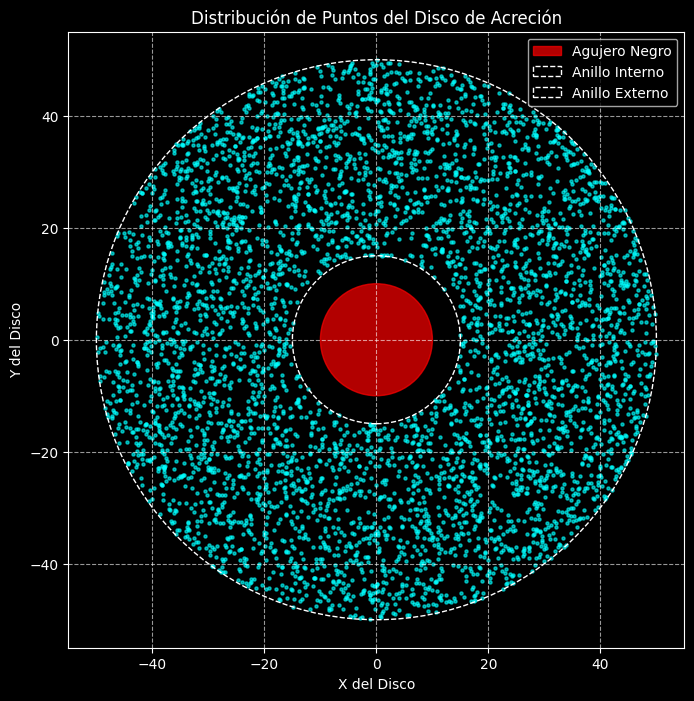

In [21]:
# Opcional: Visualizar la distribución de los puntos del disco
plt.figure(figsize=(8, 8))
plt.style.use('dark_background')
plt.scatter(x_disk, y_disk, s=5, alpha=0.6, color='cyan')
plt.title('Distribución de Puntos del Disco de Acreción')
plt.xlabel('X del Disco')
plt.ylabel('Y del Disco')
plt.gca().set_aspect('equal')
plt.grid(True, linestyle='--', alpha=0.6)

# Dibujar el agujero negro y los límites del anillo para referencia
if 'A' in globals():
    black_hole_circle = plt.Circle((0, 0), A, color='red', alpha=0.7, label='Agujero Negro')
    plt.gca().add_patch(black_hole_circle)
inner_ring = plt.Circle((0, 0), R_int, color='white', fill=False, linestyle='--', label='Anillo Interno')
outer_ring = plt.Circle((0, 0), R_ext, color='white', fill=False, linestyle='--', label='Anillo Externo')
plt.gca().add_patch(inner_ring)
plt.gca().add_patch(outer_ring)
plt.legend()
plt.show()

Para que más adelante sea verificable si los rayos intersectan el disco, estimaremos el espaciamiento promedio entre puntos del disco según

$ d_{ave} ≈ \sqrt{πR^2_{out}/N_d}$


In [28]:
# Estimar el espaciamiento promedio entre puntos del disco

d_ave = np.sqrt(np.pi * R_ext**2 / Nd)

print(f"El espaciamiento promedio (d_ave) entre los puntos del disco es: \n{d_ave:.4f}")

El espaciamiento promedio (d_ave) entre los puntos del disco es: 
1.2533


Inclinaremos el disco un ángulo i = 20° respecto al observador, rotándolo alrededor de y

In [33]:
from scipy.spatial.transform import Rotation

# Ángulo de inclinación del disco en grados
i = 20
i_rad = np.deg2rad(i)

# Asumiendo que el disco está inicialmente en el plano XY (z_disk = 0)
# Creamos un array 3D de puntos del disco
disk_points_3d = np.array([x_disk, y_disk, np.zeros_like(x_disk)]).T

# Crear un objeto de rotación alrededor del eje Y
rotation_y = Rotation.from_euler('y', i_rad)

# Aplicar la rotación a los puntos del disco
disk_points_rotated = rotation_y.apply(disk_points_3d)

# Extraer las nuevas coordenadas rotadas
x_disk_rotated = disk_points_rotated[:, 0]
y_disk_rotated = disk_points_rotated[:, 1]
z_disk_rotated = disk_points_rotated[:, 2]

# Actualizar las variables del disco
x_disk = x_disk_rotated
y_disk = y_disk_rotated
z_disk = z_disk_rotated

print(f"Disco rotado {i}° alrededor del eje Y.")
print(f"Primeras 5 posiciones x_disk_rotated: {x_disk[:5]}")
print(f"Primeras 5 posiciones y_disk_rotated: {y_disk[:5]}")
print(f"Primeras 5 posiciones z_disk_rotated: {z_disk[:5]}")

Disco rotado 20° alrededor del eje Y.
Primeras 5 posiciones x_disk_rotated: [-18.66055174 -25.66697272  26.45219425 -21.6726498  -17.22892116]
Primeras 5 posiciones y_disk_rotated: [-31.41364248  -0.90679211 -26.13991045  37.07638334  23.73252307]
Primeras 5 posiciones z_disk_rotated: [ 6.79188539  9.34201407 -9.62781134  7.88819942  6.27081447]


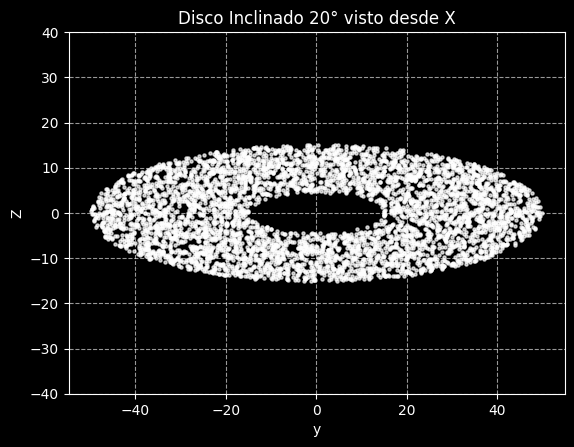

In [37]:
# Visualización del disco inclinado

plt.style.use('dark_background')

scatter_plot = plt.scatter(y_disk, z_disk, s=5, alpha=0.7, color='white')
plt.title(f'Disco Inclinado {i}° visto desde X')
plt.xlabel('y')
plt.ylabel('Z')
plt.ylim(-40,40)
plt.gca().set_aspect('equal')
plt.grid(True, linestyle='--', alpha=0.6)

### Parte 4: Intersecciones Rayo-Disco en 3D y Síntesis de la Imagen


Pasamos a la geometría 3D, cada trayectoria vive en xy, el rayo real se obtiene rotando theta alrededor de x.
Para la intersección, vemos si algún punto queda a una distancia menor a d_ave

In [41]:
# Rotación

def Rx(theta):
    # Matriz de rotación 3D alrededor del eje x.
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[1, 0, 0], [0, c, -s], [0, s, c]])

# Aplicamos la transformación a todos los rayos usando sus respectivos ángulos de lanzamiento (theta0)
all_ray_trajectories_3d = []

for i in range(len(all_ray_trajectories)):
    trajectory = all_ray_trajectories[i]
    # Extraemos solo las posiciones x, y de la trayectoria original (2D)
    x_2d = trajectory[:, 0]
    y_2d = trajectory[:, 1]

    # En el plano de integración xy original, la coordenada z es inicialmente 0
    z_2d = np.zeros_like(x_2d)

    # Matriz de posiciones 3D
    pts_3d = np.vstack((x_2d, y_2d, z_2d)).T

    # Aplicamos la rotación Rx(theta0[i]) a cada punto de la trayectoria
    rot_matrix = Rx(theta0[i])
    pts_3d_rotated = np.dot(pts_3d, rot_matrix.T)

    all_ray_trajectories_3d.append(pts_3d_rotated)

Verifique si cada rayo intersecta el disco midiendo la distancia 3D entre puntos del rayo y puntos del
disco, de manera que si alg ́un punto del rayo est ́a a menos de una distancia dave de alg ́un punto del
disco, hay una intersecci ́on. Registre la distancia radial respecto al agujero negro en la que ocurre la intersecci ́on, o un valor nulo
(p.ej. -999) si no ocurre ninguna intersecci ́on.

In [44]:
from scipy.spatial.distance import cdist

rays_intersecting_disk = np.zeros(len(all_ray_trajectories_3d), dtype=bool)
# Inicializar un array para almacenar las distancias radiales en la intersección, por defecto -999
intersection_radial_distances = np.full(len(all_ray_trajectories_3d), -999.0)

for ray_idx, ray_trajectory_3d in enumerate(all_ray_trajectories_3d):
    # ray_trajectory_3d es una matriz de (N_puntos_rayo x 3)

    found_intersection = False
    for point_idx, ray_point in enumerate(ray_trajectory_3d):
        # Calcular distancias de este punto del rayo a todos los puntos del disco rotado
        # cdist espera arrays 2D, por lo que se remodela ray_point a (1, 3)
        distances_to_disk = cdist(ray_point.reshape(1, -1), disk_points_rotated)

        # Si este punto del rayo está lo suficientemente cerca de algún punto del disco
        if np.any(distances_to_disk < d_ave):
            rays_intersecting_disk[ray_idx] = True
            # Calcular la distancia radial para este punto específico del rayo
            radial_dist_at_intersection = np.linalg.norm(ray_point) # Distancia desde el origen (agujero negro)
            intersection_radial_distances[ray_idx] = radial_dist_at_intersection
            found_intersection = True
            break # Salir del bucle interno (sobre puntos del rayo) ya que se encontró la primera intersección
    # Si no se encontró intersección para este rayo, su valor en intersection_radial_distances permanece -999.0

num_intersecting_rays = np.sum(rays_intersecting_disk)
print(f"Número de rayos que intersectan el disco: {num_intersecting_rays}")
print(f"Proporción de rayos que intersectan el disco: {num_intersecting_rays / len(all_ray_trajectories_3d):.2f}")

Número de rayos que intersectan el disco: 117
Proporción de rayos que intersectan el disco: 0.23


In [47]:
# Verificación gráfica de qué rayos intersectan el disco

